=== FFT ANALYSIS ===


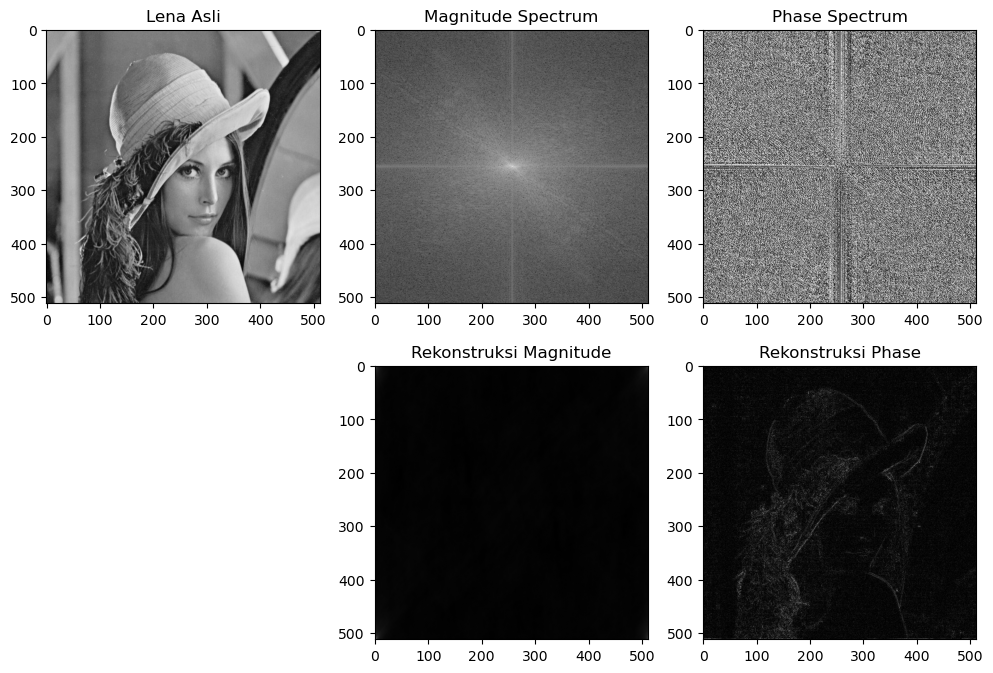

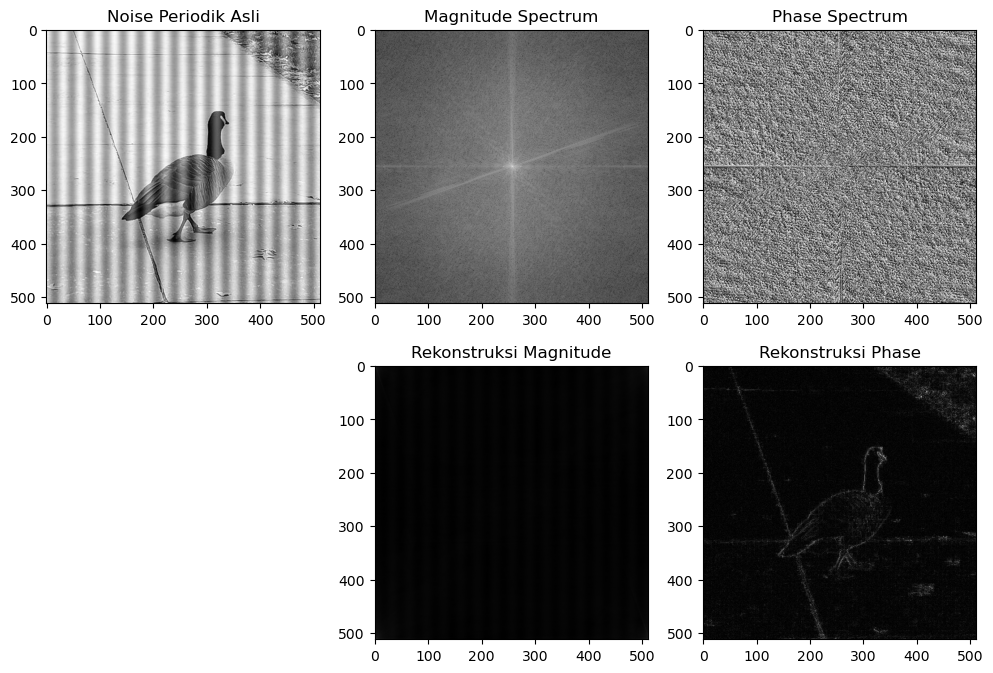


=== FILTERING ===


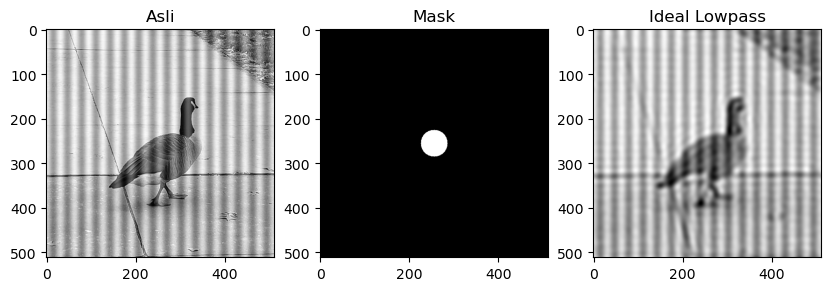

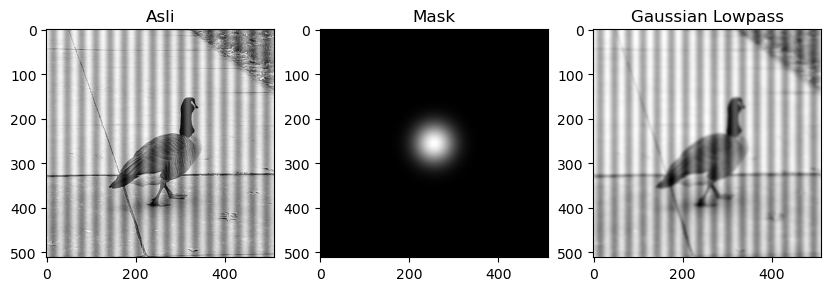

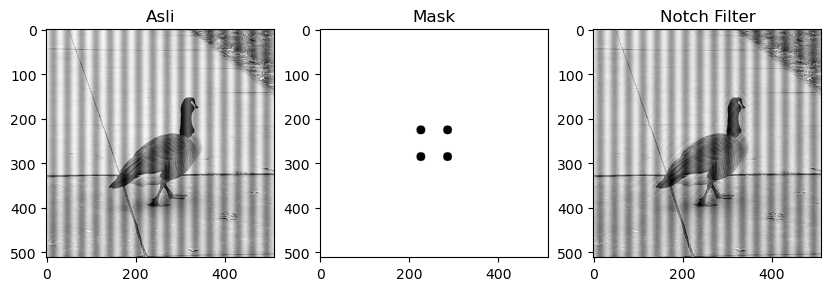


=== WAVELET ===


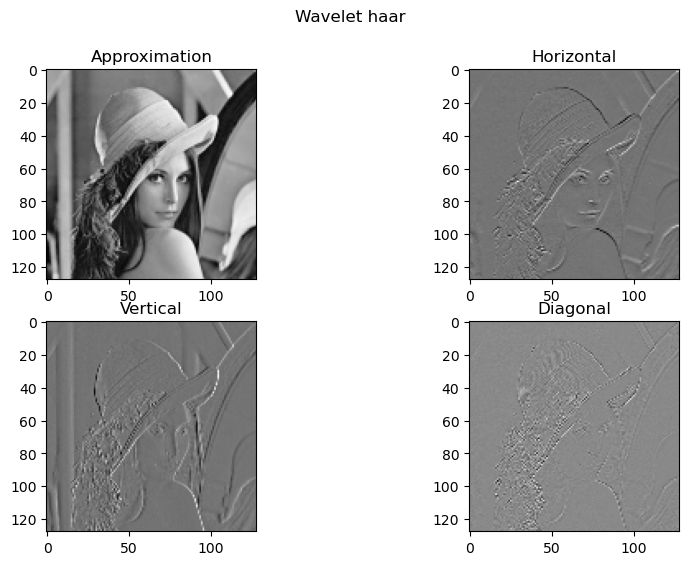

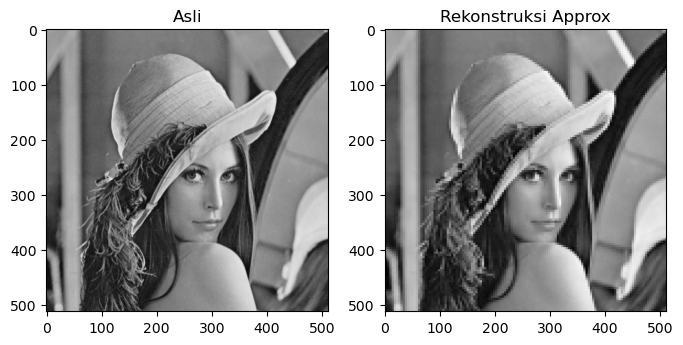

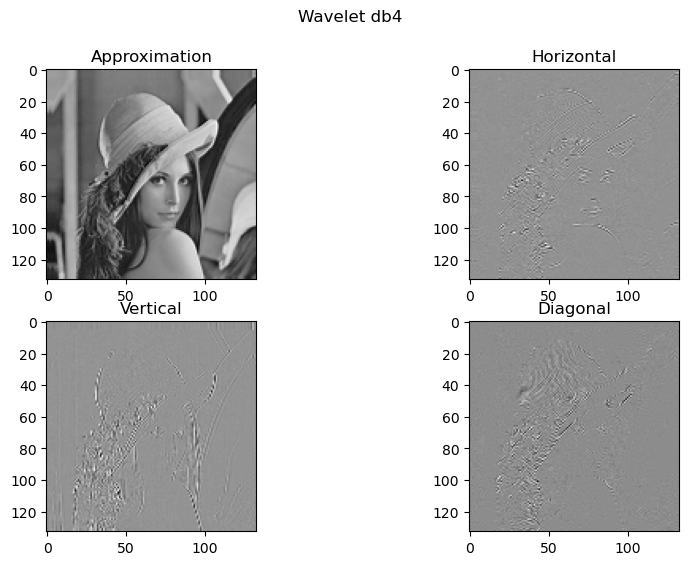

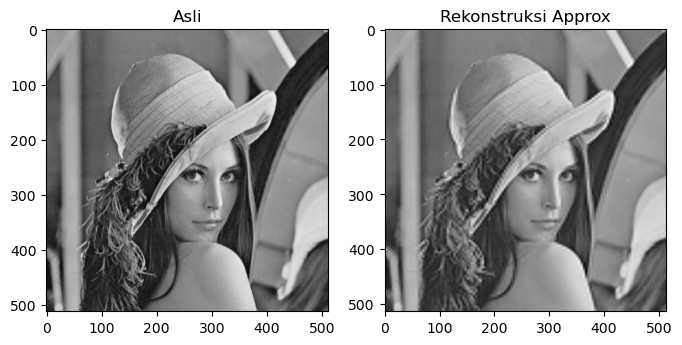


=== EVALUASI ===
Metode		PSNR(dB)	Waktu(detik)
------------------------------------------------
ILPF		24.55		1.9406
GLPF		25.06		2.8052
NOTCH		40.44		0.7353

Waktu Wavelet: 3.7024 detik


In [6]:
# ==============================================================
# ANALISIS DAN FILTERING DOMAIN FREKUENSI (FFT & WAVELET)
# ==============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
import pywt
import time

# ==============================================================
# LOAD IMAGE
# ==============================================================

img_natural = cv2.imread('lena.jpeg', 0)
img_noise = cv2.imread('noise_periodic.jpeg', 0)

# ==============================================================
# FFT ANALYSIS
# ==============================================================

def fft_analysis(img, title):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    magnitude = np.log(1 + np.abs(fshift))
    phase = np.angle(fshift)

    # Rekonstruksi
    mag_only = np.abs(fshift)
    phase_only = np.exp(1j * phase)

    img_mag = np.fft.ifft2(np.fft.ifftshift(mag_only))
    img_phase = np.fft.ifft2(np.fft.ifftshift(phase_only))

    plt.figure(figsize=(12,8))
    
    plt.subplot(2,3,1)
    plt.imshow(img, cmap='gray')
    plt.title(f'{title} Asli')

    plt.subplot(2,3,2)
    plt.imshow(magnitude, cmap='gray')
    plt.title('Magnitude Spectrum')

    plt.subplot(2,3,3)
    plt.imshow(phase, cmap='gray')
    plt.title('Phase Spectrum')

    plt.subplot(2,3,5)
    plt.imshow(np.abs(img_mag), cmap='gray')
    plt.title('Rekonstruksi Magnitude')

    plt.subplot(2,3,6)
    plt.imshow(np.abs(img_phase), cmap='gray')
    plt.title('Rekonstruksi Phase')

    plt.show()

# ==============================================================
# FILTER MASK
# ==============================================================

def ideal_lowpass(shape, cutoff):
    rows, cols = shape
    mask = np.zeros((rows, cols))
    center = (rows//2, cols//2)

    for i in range(rows):
        for j in range(cols):
            d = np.sqrt((i-center[0])**2 + (j-center[1])**2)
            if d <= cutoff:
                mask[i,j] = 1
    return mask

def ideal_highpass(shape, cutoff):
    return 1 - ideal_lowpass(shape, cutoff)

def gaussian_lowpass(shape, cutoff):
    rows, cols = shape
    mask = np.zeros((rows, cols))
    center = (rows//2, cols//2)

    for i in range(rows):
        for j in range(cols):
            d = np.sqrt((i-center[0])**2 + (j-center[1])**2)
            mask[i,j] = np.exp(-(d**2)/(2*(cutoff**2)))
    return mask

def gaussian_highpass(shape, cutoff):
    return 1 - gaussian_lowpass(shape, cutoff)

# ==============================================================
# APPLY FILTER
# ==============================================================

def apply_filter(img, mask, title):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    filtered = fshift * mask

    img_back = np.fft.ifft2(np.fft.ifftshift(filtered))
    img_back = np.abs(img_back)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Asli")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")

    plt.subplot(1,3,3)
    plt.imshow(img_back, cmap='gray')
    plt.title(title)

    plt.show()

    return img_back

# ==============================================================
# NOTCH FILTER (UNTUK NOISE PERIODIK)
# ==============================================================

def notch_filter(shape, radius=10):
    rows, cols = shape
    mask = np.ones((rows, cols))

    center = (rows//2, cols//2)

    # titik noise (biasanya simetris dari tengah)
    points = [
        (center[0]+30, center[1]+30),
        (center[0]-30, center[1]-30),
        (center[0]+30, center[1]-30),
        (center[0]-30, center[1]+30)
    ]

    for (x,y) in points:
        cv2.circle(mask, (y,x), radius, 0, -1)

    return mask

# ==============================================================
# WAVELET
# ==============================================================

def wavelet_analysis(img, wavelet_name):
    coeffs = pywt.wavedec2(img, wavelet_name, level=2)

    cA2, (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs

    plt.figure(figsize=(10,6))

    plt.subplot(2,2,1)
    plt.imshow(cA2, cmap='gray')
    plt.title('Approximation')

    plt.subplot(2,2,2)
    plt.imshow(cH2, cmap='gray')
    plt.title('Horizontal')

    plt.subplot(2,2,3)
    plt.imshow(cV2, cmap='gray')
    plt.title('Vertical')

    plt.subplot(2,2,4)
    plt.imshow(cD2, cmap='gray')
    plt.title('Diagonal')

    plt.suptitle(f'Wavelet {wavelet_name}')
    plt.show()

    # Rekonstruksi hanya approximation
    coeffs_new = [cA2, (None, None, None), (None, None, None)]
    reconstructed = pywt.waverec2(coeffs_new, wavelet_name)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Asli")

    plt.subplot(1,2,2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title("Rekonstruksi Approx")

    plt.show()

# ==============================================================
# METRIK
# ==============================================================

def mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

def psnr(img1, img2):
    m = mse(img1, img2)
    return 20 * np.log10(255.0 / np.sqrt(m))

# ==============================================================
# MAIN
# ==============================================================

print("=== FFT ANALYSIS ===")
fft_analysis(img_natural, "Lena")
fft_analysis(img_noise, "Noise Periodik")

print("\n=== FILTERING ===")

# Ideal Lowpass
start = time.time()
ilpf = ideal_lowpass(img_noise.shape, 30)
res_ilpf = apply_filter(img_noise, ilpf, "Ideal Lowpass")
time_ilpf = time.time() - start

# Gaussian Lowpass
start = time.time()
glpf = gaussian_lowpass(img_noise.shape, 30)
res_glpf = apply_filter(img_noise, glpf, "Gaussian Lowpass")
time_glpf = time.time() - start

# Notch Filter
start = time.time()
notch = notch_filter(img_noise.shape, radius=10)
res_notch = apply_filter(img_noise, notch, "Notch Filter")
time_notch = time.time() - start


print("\n=== WAVELET ===")
start = time.time()

wavelet_analysis(img_natural, 'haar')
wavelet_analysis(img_natural, 'db4')

time_wavelet = time.time() - start

print("\n=== EVALUASI ===")
print("Metode\t\tPSNR(dB)\tWaktu(detik)")
print("------------------------------------------------")

print("ILPF\t\t%.2f\t\t%.4f" % (psnr(img_noise, res_ilpf), time_ilpf))
print("GLPF\t\t%.2f\t\t%.4f" % (psnr(img_noise, res_glpf), time_glpf))
print("NOTCH\t\t%.2f\t\t%.4f" % (psnr(img_noise, res_notch), time_notch))

print("\nWaktu Wavelet: %.4f detik" % time_wavelet)